In [8]:
import matplotlib.pyplot as plt
import polars as pl
from polars import col as c
import pandas as pd
from datetime import date

from src.utils.my_plotting import *
from src.signals.combine import make_signal

In [9]:
INPUT = '../data/processed/features.parquet'

In [10]:
lf = pl.scan_parquet(INPUT).sort(['ticker', 'date'])

In [11]:
df = lf.filter(
    c('ticker').is_in( c('ticker').unique().sample(10).implode() )
).collect()

## Individual signal

In [12]:
def pivot_wide(df, value_col, index='date', on='ticker'):
    '''
    Long (ticker, date, value) panel -> wide (date rows, ticker columns). Requires an already-collected pl.DataFrame. 
        This is useful for a per-ticker time series plot, or a ticker-ticker correlation matrix of a signal.
    '''
    if isinstance(df, pl.LazyFrame):
        df = df.collect()
    return df.pivot(index=index, on=on, values=value_col, aggregate_function='first')

In [13]:
feature = 'mom20'
signal_method = 'decile'
df_signals = pivot_wide(
    make_signal(df, feature, signal_method), 
    f'{feature}_{signal_method}', 
    index='date',
    on='ticker',
).to_pandas().set_index('date')

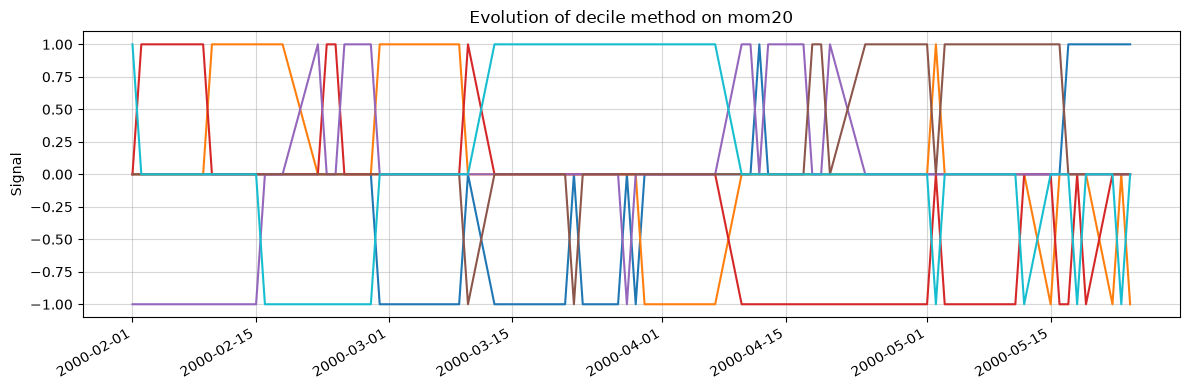

In [17]:
f, ax = new_fig(fs=(12, 4))
df_signals.iloc[:100].plot(ax=ax, legend=False)
finish_fig(ax=ax, legend=False, title=f'Evolution of {signal_method} method on {feature}', yl='Signal')

## Signal Comparison

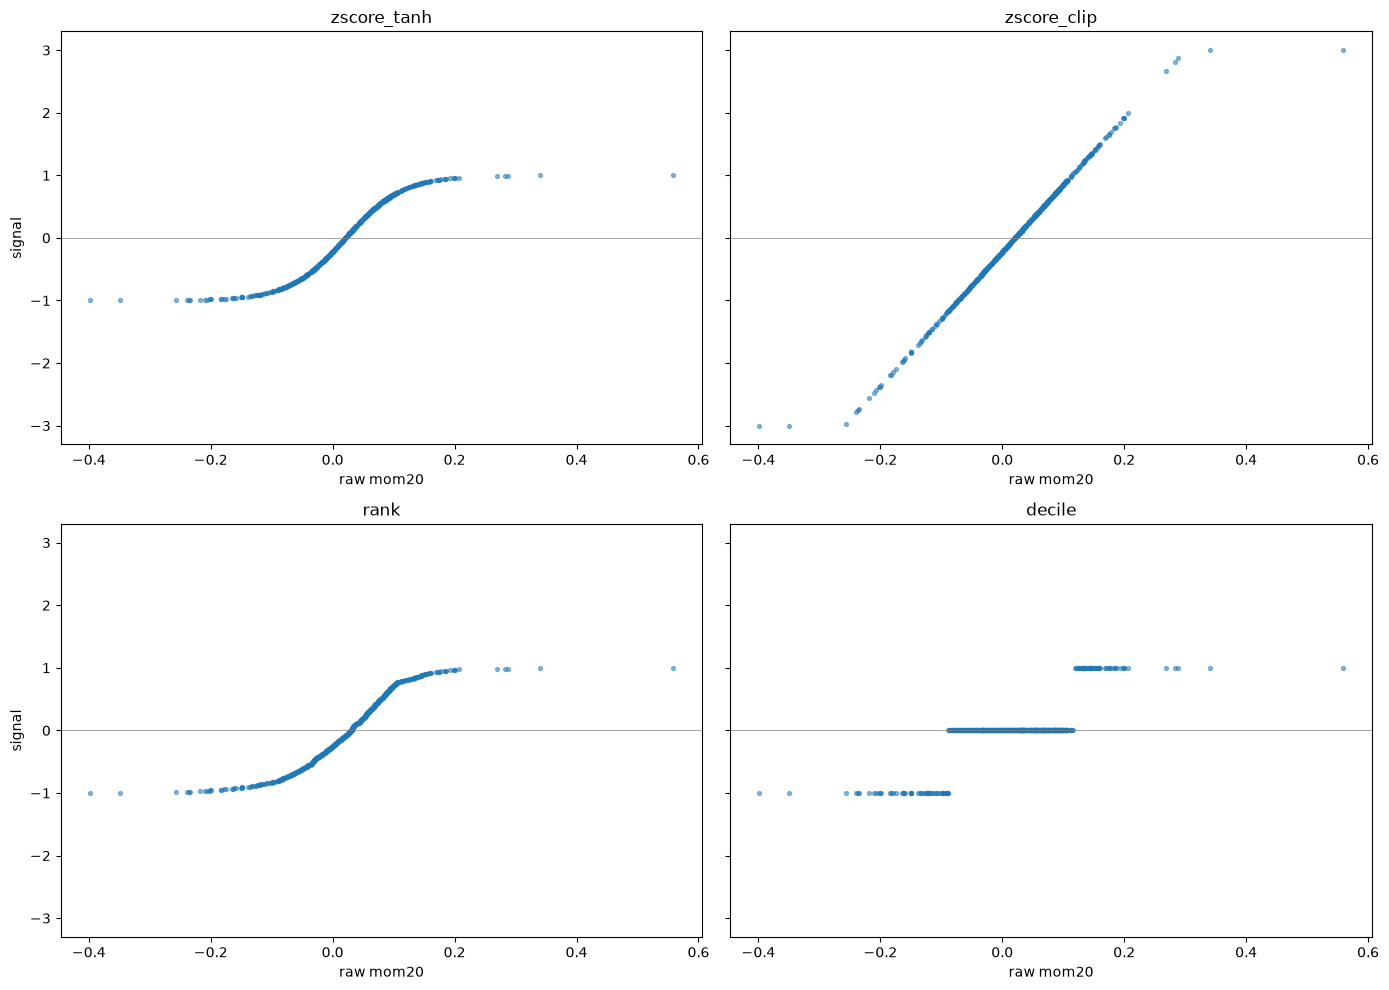

In [29]:
feature = 'mom20'
one_date = lf.filter(c('date') == c('date').max())
methods = ['zscore_tanh', 'zscore_clip', 'rank', 'decile']
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for ax, method in zip(axes.flatten(), methods):
    signal_col = f'{feature}_{method}'
    out = make_signal(one_date.lazy(), feature, method=method).collect()
    ax.scatter(out[feature], out[signal_col], s=8, alpha=0.5)
    ax.set_title(method)
    ax.set_xlabel(f'raw {feature}')
    ax.axhline(0, color='grey', lw=0.5)

axes[0, 0].set_ylabel('signal');axes[1, 0].set_ylabel('signal')
plt.tight_layout()
plt.show()